In [2]:
import wget
import tarfile
import os
import time
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib import rc
import sys
import numpy.core.numeric as numeric
import numpy as np

In [3]:
df_sm = pd.read_pickle("/home/jpittard/depot/top/jpittard/Purdue_Analysis_EFT/pickel_files/sm_pickle/events_0.pkl.gz")
df_eft_lin = pd.read_pickle("/depot/cms/top/jpittard/Purdue_Analysis_EFT/pickel_files/sm_lin_pickles_15/tt_ctGRe/events_0.pkl.gz")
df_eft_quad1 = pd.read_pickle("/depot/cms/top/jpittard/Purdue_Analysis_EFT/pickel_files/sm_lin_quad_pickles_15/tt_ctGRe/events_0.pkl.gz")
#df_eft_quad2 = pd.read_pickle("/depot/cms/top/jpittard/Purdue_Analysis_EFT/pickel_files/sm_quad_pickles_15/tt_ctGRe/events_0.pkl.gz")

df_eft_quad1

,gen_ttbar_mass,gen_b1k,gen_b2k,gen_b1r,gen_b2r,gen_b1n,gen_b2n,gen_c_nn,gen_c_rr,gen_c_kk,gen_ll_cHel,gen_ll_cLab,gen_llbar_delta_phi,gen_ttbar_rapidity,gen_b1q,gen_llbar_pt,gen_l_eta
0,391.055817,0.907170,-0.038775,0.273120,0.811421,-0.320075,0.583175,-0.186660,0.221615,-0.035176,0.000220,0.551972,0.661791,-1.353950,-0.273120,76.544373,-2.133993
1,1067.822144,0.313013,0.211856,-0.636944,0.742252,0.704504,0.635750,0.447888,-0.472773,0.066314,-0.041429,-0.679028,3.069330,-0.697487,-0.636944,67.868729,-0.009563
2,491.312042,0.767301,0.501544,-0.583778,-0.091281,0.265428,0.860303,0.228349,0.053288,0.384835,-0.666472,-0.555831,2.398268,-0.760492,-0.583778,35.185181,0.333495
3,413.167969,0.574432,0.846855,0.547135,0.528620,0.608827,-0.058283,-0.035484,0.289227,0.486461,-0.740203,0.246412,2.273892,1.136909,0.547135,43.231583,0.495447
4,489.231934,0.191838,-0.081052,0.930524,0.419673,-0.311967,0.904049,-0.282034,0.390516,-0.015549,-0.092933,-0.666802,2.189799,-0.183511,-0.930524,74.145844,-0.527787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14999995,451.433716,-0.249931,-0.309183,0.228413,0.374616,-0.940937,0.874110,-0.822482,0.085567,0.077274,0.659641,0.731652,0.799645,0.925094,-0.228413,82.082458,1.439075
14999996,401.645721,-0.631555,-0.310824,0.138043,-0.319007,-0.762944,-0.895334,0.683089,-0.044037,0.196302,-0.835355,0.263891,2.734939,0.921060,0.138043,12.417736,1.049103
14999997,406.949463,0.433818,-0.978782,0.057657,0.180266,-0.899154,-0.097418,0.087593,0.010394,-0.424613,0.326626,0.544932,1.346415,-0.141070,-0.057657,70.637367,0.739788
14999998,380.978729,-0.853899,-0.444627,0.292814,-0.172076,0.430252,0.879032,0.378205,-0.050386,0.379666,-0.707485,0.407577,2.220373,1.245780,-0.292814,44.805454,1.006614


In [4]:
df_eft_lin

,gen_ttbar_mass,gen_b1k,gen_b2k,gen_b1r,gen_b2r,gen_b1n,gen_b2n,gen_c_nn,gen_c_rr,gen_c_kk,gen_ll_cHel,gen_ll_cLab,gen_llbar_delta_phi,gen_ttbar_rapidity,gen_b1q,gen_llbar_pt,gen_l_eta
0,452.607452,-0.714813,0.396152,0.581762,0.650797,-0.388066,0.647709,-0.251354,0.378609,-0.283175,0.155920,0.183726,0.619829,-0.146382,0.581762,131.218582,0.999217
1,539.973938,-0.642679,0.222070,-0.733498,-0.771695,0.221236,0.595962,0.131848,0.566037,-0.142720,-0.555165,-0.795465,3.089576,-0.790583,-0.733498,101.343887,-0.683633
2,419.278473,0.041970,0.336746,0.881602,0.066985,-0.470124,-0.939210,0.441545,0.059054,0.014133,-0.514733,-0.218760,2.881414,0.694111,0.881602,32.363354,0.250981
3,794.263489,-0.049179,0.166738,-0.579818,-0.809882,0.813261,-0.562396,-0.457375,0.469584,-0.008200,-0.004009,-0.906870,2.998376,0.182820,-0.579818,100.286491,-0.063427
4,388.804901,-0.443933,0.624510,0.102055,-0.776514,0.890229,-0.083748,-0.074555,-0.079247,-0.277241,0.431042,0.322035,1.470574,0.871957,-0.102055,50.034576,0.413879
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14999995,455.919586,-0.794320,0.540739,-0.457109,-0.189003,-0.400133,0.819682,-0.327982,0.086395,-0.429520,0.671107,0.773052,1.375736,-0.512942,0.457109,70.071236,-1.303794
14999996,517.645508,0.948925,-0.242409,-0.190515,-0.892297,0.251488,-0.380846,-0.095778,0.169996,-0.230028,0.155810,0.914878,2.653486,-1.872421,-0.190515,87.085747,-2.598275
14999997,461.942627,0.283285,-0.962513,-0.144141,0.236345,0.948142,-0.133076,-0.126175,-0.034067,-0.272666,0.432907,0.864567,0.388946,0.431480,-0.144141,63.622013,0.217123
14999998,562.572693,0.405826,-0.967805,-0.375724,0.037170,0.833149,0.248943,0.207407,-0.013966,-0.392760,0.199319,0.730523,1.510609,0.446805,-0.375724,75.360550,1.135027


In [5]:
df_sm

,gen_ttbar_mass,gen_b1k,gen_b2k,gen_b1r,gen_b2r,gen_b1n,gen_b2n,gen_c_nn,gen_c_rr,gen_c_kk,gen_ll_cHel,gen_ll_cLab,gen_llbar_delta_phi,gen_ttbar_rapidity,gen_b1q,gen_llbar_pt,gen_l_eta
0,424.349976,0.081279,-0.779212,0.273973,-0.626483,-0.958297,-0.018644,0.017867,-0.171639,-0.063334,0.217106,-0.013411,1.712932,1.220394,-0.273973,53.078136,0.256359
1,604.758606,-0.120048,-0.572445,-0.980356,-0.778357,0.156494,-0.257812,-0.040346,0.763067,0.068721,-0.791442,0.710151,3.030710,-1.428018,-0.980356,13.852571,-1.896554
2,490.805054,0.680498,-0.288747,0.579948,-0.953894,0.447864,0.081922,0.036690,-0.553209,-0.196492,0.713011,-0.659095,1.227223,-1.271203,-0.579948,70.899879,-1.365496
3,522.213196,0.812891,0.534840,0.305486,0.281247,-0.495870,-0.796773,0.395096,0.085917,0.434766,-0.915779,-0.757952,3.074207,0.674764,0.305486,5.202093,-0.724560
4,385.527161,0.895347,-0.838421,0.336847,0.365893,-0.291355,-0.403947,0.117692,0.123250,-0.750678,0.509736,0.700100,0.857270,0.711329,0.336847,75.918640,0.555985
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14999995,858.739014,0.901504,0.413533,-0.011862,0.337287,0.432609,0.845711,0.365862,-0.004001,0.372802,-0.734663,-0.915634,2.955488,0.300898,-0.011862,108.037643,-0.473318
14999996,404.454071,0.790931,-0.380505,-0.249012,-0.398691,0.558947,-0.834423,-0.466398,0.099279,-0.300953,0.668072,-0.474832,2.198879,-0.757602,0.249012,33.087547,-0.877547
14999997,666.485291,-0.301023,0.212773,0.411225,-0.901026,-0.860395,-0.377995,0.325225,-0.370524,-0.064050,0.109349,-0.217708,1.241203,-0.557264,0.411225,87.049355,0.419111
14999998,428.952209,-0.611850,-0.053881,-0.782975,0.647755,-0.112206,0.759941,-0.085270,-0.507176,0.032967,0.559478,0.958723,1.073500,-1.310081,0.782975,46.775517,-2.255891


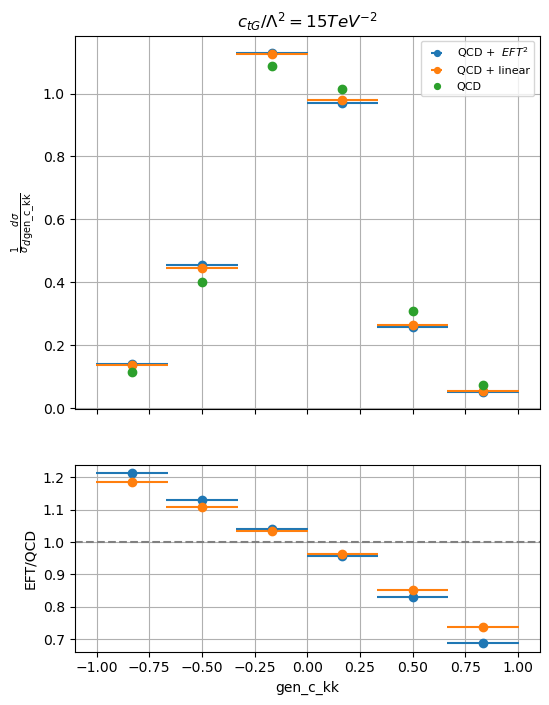

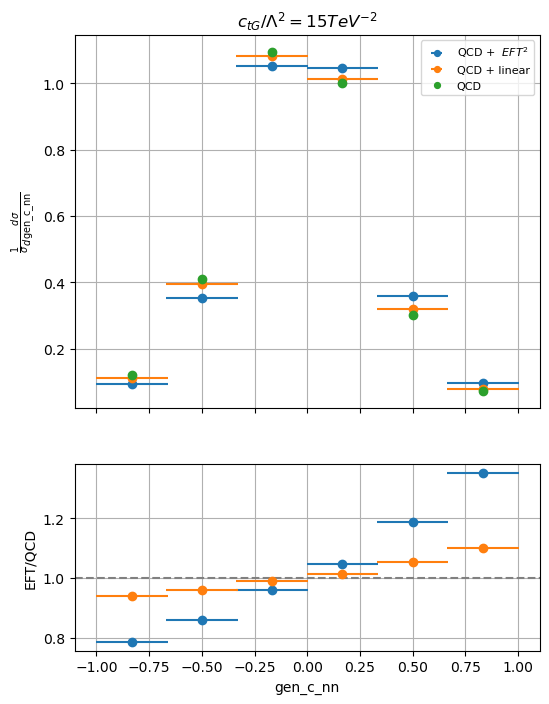

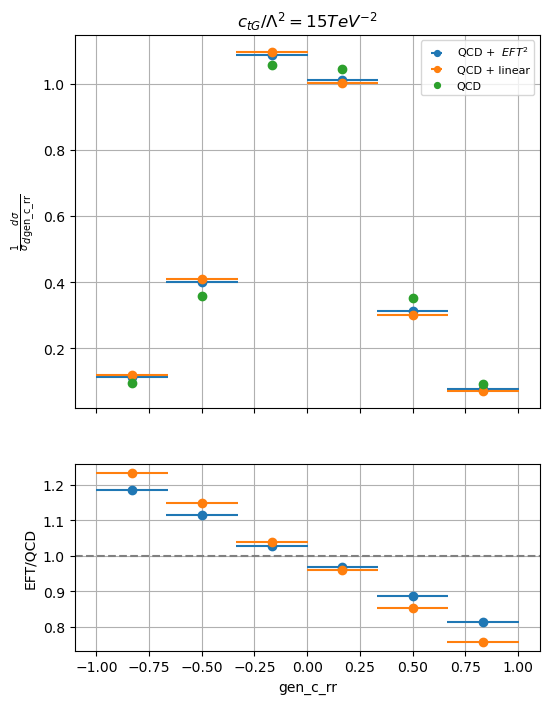

In [6]:
var_names = ['gen_c_kk','gen_c_nn','gen_c_rr']

label_0 = 'QCD'
label_1 = 'QCD + linear'
label_2 = r'QCD +  $EFT^2$'

bins=6
density=True

for var in var_names:
    sm_data = np.asarray(df_sm[var])
    lin_data = np.asarray(df_eft_lin[var])
    quad_data = np.asarray(df_eft_quad1[var])

    # Special binning for gen_ttbar_mass
    if var == "gen_ttbar_mass":
        bin_edges = np.linspace(350, 1500, bins+1)  # 50 bins from 300 to 1500
    else:
        combined = np.concatenate([sm_data, lin_data, quad_data])
        bin_edges = np.linspace(np.min(combined), np.max(combined), bins + 1)

    # Histogram counts
    counts0, _ = np.histogram(sm_data, bins=bin_edges, density=density)
    counts1, _ = np.histogram(lin_data, bins=bin_edges, density=density)
    counts2, _ = np.histogram(quad_data, bins=bin_edges, density=density)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8),
                                   gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

    
    
    # Top: Distributions
    ax1.errorbar(bin_centers, counts2, xerr = 0.17, fmt='o', label=label_2)
    ax1.errorbar(bin_centers, counts1, xerr = 0.17, fmt='o', label=label_1)
    ax1.errorbar(bin_centers, counts0, fmt='o', label=label_0)
    label = r'$\frac{1}{\sigma} \frac{d\sigma}{d\text{' + var + r'}}$'
    ax1.set_ylabel(label)
    ax1.set_title(r'$c_{tG}/\Lambda^{2} = 15 TeV^{-2}$')
    ax1.legend(prop={'size': 8}, markerscale=0.7)
    ax1.grid(True)

    # Bottom: Ratios
    counts0_safe = np.where(counts0 > 0, counts0, np.nan)
    ratio1 = counts1 / counts0_safe
    ratio2 = counts2 / counts0_safe
    ax2.errorbar(bin_centers, ratio2, xerr = 0.17, fmt='o', label=f"{label_2} / {label_0}")
    ax2.errorbar(bin_centers, ratio1, xerr = 0.17, fmt='o', label=f"{label_1} / {label_0}")
    ax2.set_xlabel(var)
    ax2.set_ylabel("EFT/QCD")
    ax2.axhline(1.0, color='gray', linestyle='--')
    #ax2.legend()
    ax2.grid(True)

    # Apply log y-axis and x-limit only for gen_ttbar_mass
    if var == "gen_ttbar_mass":
        ax1.set_yscale('log')
        ax1.set_xlim(300, 1500)
        ax2.set_xlim(300, 1500)

    #plt.tight_layout()
    plt.show()